# 1 . Creation dataframe pandas from dataset Sentinel

In [85]:
from pathlib import Path

import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

candidate_input_path = (
    project_root
    / "data"
    / "interim"
    / "sentinel5p_ch4_po_valley_candidate_2024.nc"
)

candidate_ds = xr.open_dataset(candidate_input_path)
ch4_candidate = candidate_ds["CH4"]

candidate_ds

In [ ]:
candidate_cells_df = (
    candidate_ds["candidate_mask"]
    .to_dataframe(name="candidate_mask")
    .reset_index()
)

candidate_cells_df = (
    candidate_cells_df.loc[
        candidate_cells_df["candidate_mask"].astype(bool),
        ["y", "x"],
    ]
    .copy()
)

candidate_cells_df.head()

In [ ]:
ch4_df = (
    ch4_candidate
    .to_dataframe(name="CH4")
    .reset_index()
    .rename(columns={"t": "week"})
)

ch4_df = ch4_df.merge(
    candidate_cells_df,
    on=["y", "x"],
    how="inner",
)

ch4_df

In [89]:
cell_lookup = (
    candidate_cells_df
    .sort_values(["y", "x"])
    .reset_index(drop=True)
)

cell_lookup["cell_id"] = np.arange(
    len(cell_lookup),
    dtype=int,
)

In [90]:
ch4_df = (
    ch4_df
    .merge(
        cell_lookup,
        on=["y", "x"],
        how="left",
    )
    .sort_values(["cell_id", "week"])
    .reset_index(drop=True)
)

ch4_df = ch4_df[
    ["week", "cell_id", "y", "x", "CH4"]
]

In [91]:
number_of_weeks = ch4_df["week"].nunique()
number_of_cells = ch4_df["cell_id"].nunique()

expected_rows = number_of_weeks * number_of_cells

print("Weeks:", number_of_weeks)
print("Cells:", number_of_cells)
print("Rows:", len(ch4_df))
print("Expected rows:", expected_rows)

Weeks: 53
Cells: 2714
Rows: 143842
Expected rows: 143842


In [92]:
assert len(ch4_df) == expected_rows, (
    "The tabular dataset does not contain one row "
    "for every cell-week combination."
)

assert not ch4_df.duplicated(
    subset=["week", "cell_id"]
).any(), "Duplicate cell-week combinations found."

In [93]:
print(
    "Missing CH4 proportion:",
    ch4_df["CH4"].isna().mean(),
)

Missing CH4 proportion: 0.4157130740673795


In [94]:
candidate_ds.close()

# 2 . Exploratory data analysis

In [ ]:
print(ch4_df.info())
print(ch4_df.head())
print(ch4_df["CH4"].describe())

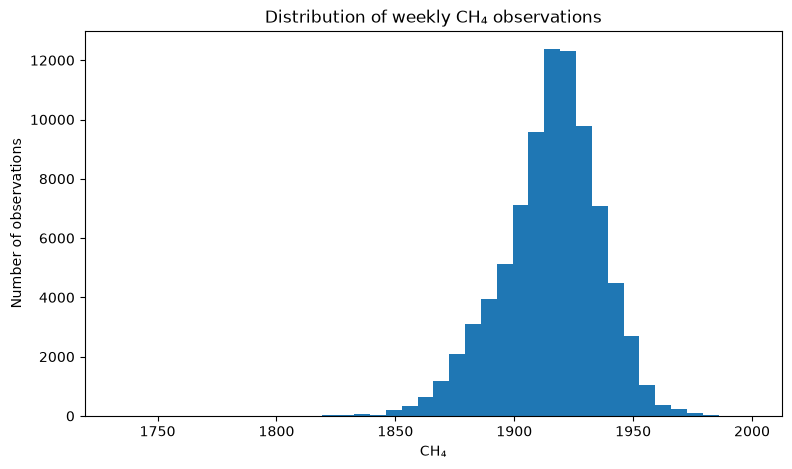

In [96]:
ch4_df["CH4"].plot.hist(
    bins=40,
    figsize=(9, 5),
)

plt.title("Distribution of weekly CH₄ observations")
plt.xlabel("CH₄")
plt.ylabel("Number of observations")
plt.show()

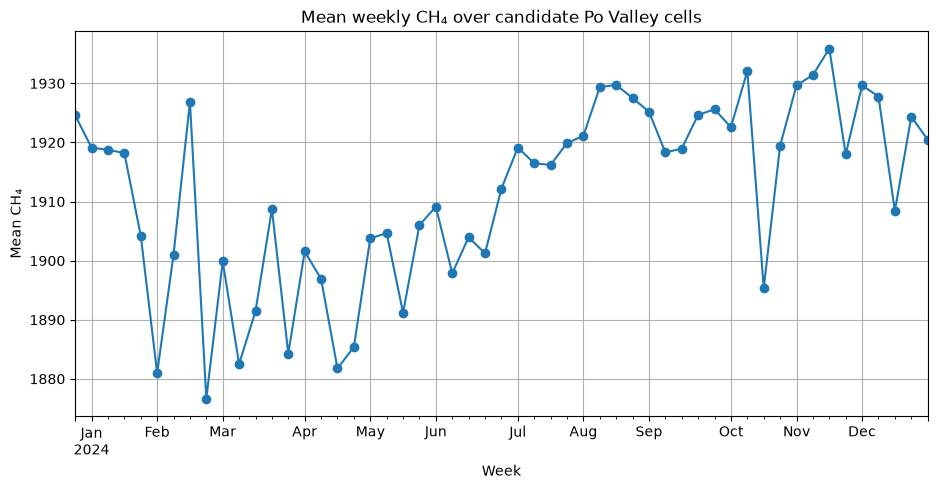

In [97]:
weekly_mean = (
    ch4_df
    .groupby("week", as_index=False)["CH4"]
    .mean()
)

weekly_mean.plot(
    x="week",
    y="CH4",
    figsize=(11, 5),
    marker="o",
    legend=False,
)

plt.title("Mean weekly CH₄ over candidate Po Valley cells")
plt.xlabel("Week")
plt.ylabel("Mean CH₄")
plt.grid()
plt.show()

In [98]:
ch4_df["target_next_week"] = (
    ch4_df
    .groupby("cell_id")["CH4"]
    .shift(-1)
)

ch4_df["next_week"] = (
    ch4_df
    .groupby("cell_id")["week"]
    .shift(-1)
)

In [99]:
ch4_df["forecast_horizon_days"] = (
    ch4_df["next_week"] - ch4_df["week"]
).dt.days

model_df = ch4_df.loc[
    ch4_df["CH4"].notna()
    & ch4_df["target_next_week"].notna()
    & ch4_df["forecast_horizon_days"].eq(7)
].copy()

In [100]:
expected_valid_pairs = int(
    candidate_ds.attrs["valid_consecutive_week_pairs"]
)

In [ ]:
print("Model-ready rows:", len(model_df))
print("Expected consecutive pairs:", expected_valid_pairs)

assert len(model_df) == expected_valid_pairs, (
    "The number of tabular samples does not match "
    "the consecutive-pair count calculated in notebook 01."
)

In [ ]:
weekly_summary = (
    ch4_df
    .groupby("week")
    .agg(
        mean_ch4=("CH4", "mean"),
        median_ch4=("CH4", "median"),
        std_ch4=("CH4", "std"),
        valid_cells=("CH4", "count"),
    )
    .reset_index()
)

weekly_summary.head()

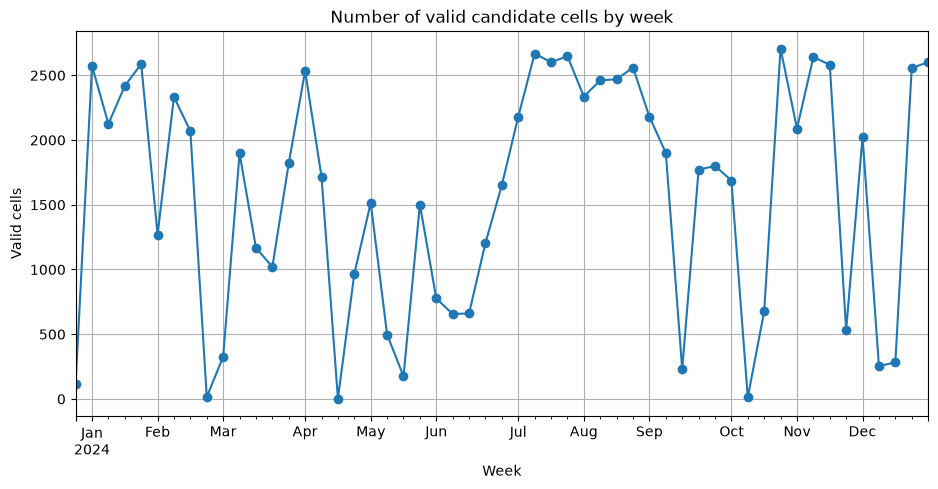

In [103]:
weekly_summary.plot(
    x="week",
    y="valid_cells",
    figsize=(11, 5),
    marker="o",
    legend=False,
)

plt.title("Number of valid candidate cells by week")
plt.xlabel("Week")
plt.ylabel("Valid cells")
plt.grid()
plt.show()

In [ ]:
weekly_summary.sort_values("median_ch4").head(10)

In [ ]:
weekly_summary[
    ["mean_ch4", "valid_cells"]
].corr()

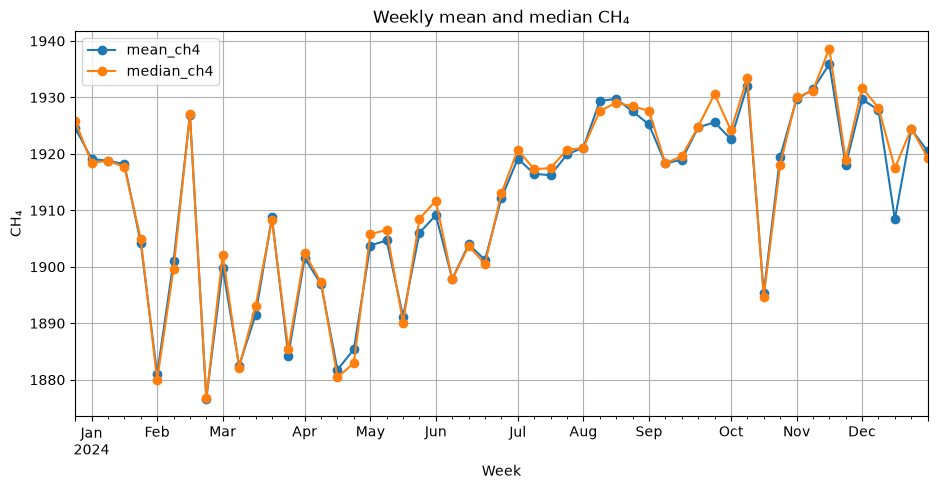

In [106]:
ax = weekly_summary.plot(
    x="week",
    y=["mean_ch4", "median_ch4"],
    figsize=(11, 5),
    marker="o",
)

ax.set_title("Weekly mean and median CH₄")
ax.set_xlabel("Week")
ax.set_ylabel("CH₄")
ax.grid()

plt.show()

In [107]:
weekly_quantiles = (
    ch4_df
    .groupby("week")["CH4"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
    .reset_index()
    .rename(columns={
        0.25: "q25",
        0.50: "median",
        0.75: "q75",
    })
)

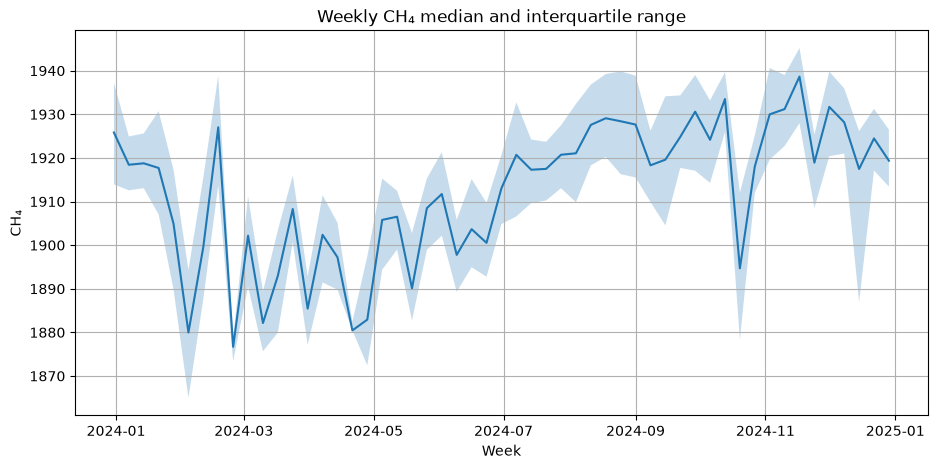

In [108]:
plt.figure(figsize=(11, 5))

plt.plot(
    weekly_quantiles["week"],
    weekly_quantiles["median"],
)

plt.fill_between(
    weekly_quantiles["week"],
    weekly_quantiles["q25"],
    weekly_quantiles["q75"],
    alpha=0.25,
)

plt.title("Weekly CH₄ median and interquartile range")
plt.xlabel("Week")
plt.ylabel("CH₄")
plt.grid()
plt.show()

In [109]:
cell_observation_counts = (
    ch4_df
    .groupby("cell_id")["CH4"]
    .count()
)

stable_cell_ids = cell_observation_counts[
    cell_observation_counts >= 40
].index

stable_weekly_mean = (
    ch4_df[
        ch4_df["cell_id"].isin(stable_cell_ids)
    ]
    .groupby("week", as_index=False)["CH4"]
    .mean()
)

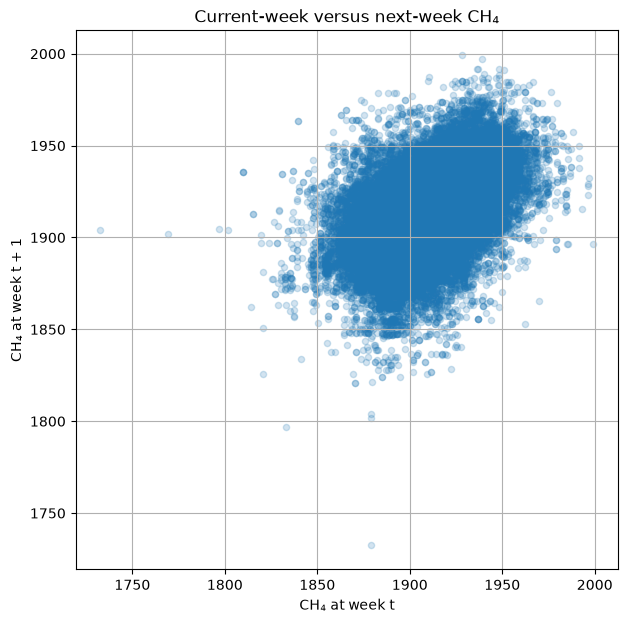

In [110]:
model_df.plot.scatter(
    x="CH4",
    y="target_next_week",
    figsize=(7, 7),
    alpha=0.2,
)

plt.title("Current-week versus next-week CH₄")
plt.xlabel("CH₄ at week t")
plt.ylabel("CH₄ at week t + 1")
plt.grid()
plt.show()

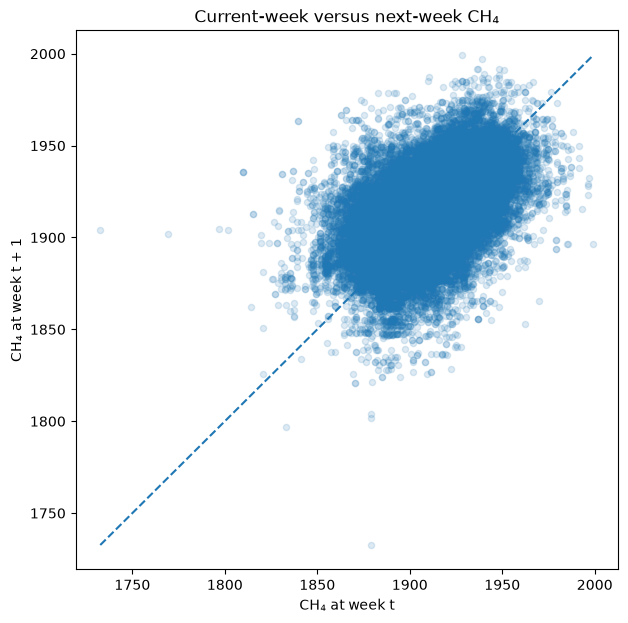

In [111]:
ax = model_df.plot.scatter(
    x="CH4",
    y="target_next_week",
    figsize=(7, 7),
    alpha=0.15,
)

lower = min(
    model_df["CH4"].min(),
    model_df["target_next_week"].min(),
)

upper = max(
    model_df["CH4"].max(),
    model_df["target_next_week"].max(),
)

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
)

ax.set_xlabel("CH₄ at week t")
ax.set_ylabel("CH₄ at week t + 1")
ax.set_title("Current-week versus next-week CH₄")

plt.show()

In [112]:
persistence_errors = (
    model_df["target_next_week"] - model_df["CH4"]
)

mean_error = persistence_errors.mean()
mae = persistence_errors.abs().mean()
rmse = np.sqrt((persistence_errors ** 2).mean())

print("Mean error:", mean_error)
print("Persistence MAE:", mae)
print("Persistence RMSE:", rmse)

Mean error: 2.2175357
Persistence MAE: 15.886544
Persistence RMSE: 20.88733


In [113]:
correlation = model_df[
    ["CH4", "target_next_week"]
].corr().iloc[0, 1]

print("Correlation:", correlation)

Correlation: 0.4822652760335266


# 3 . Feature engineering

In [114]:
feature_df = (
    ch4_df[
        ["week", "cell_id", "y", "x", "CH4"]
    ]
    .sort_values(["cell_id", "week"])
    .reset_index(drop=True)
    .copy()
)

In [115]:
grouped_ch4 = feature_df.groupby("cell_id")["CH4"]

In [116]:
feature_df["ch4_prev_1w"] = grouped_ch4.shift(1)
feature_df["ch4_prev_2w"] = grouped_ch4.shift(2)

feature_df["target_next_week"] = grouped_ch4.shift(-1)

feature_df["next_week"] = (
    feature_df
    .groupby("cell_id")["week"]
    .shift(-1)
)

feature_df["forecast_horizon_days"] = (
    feature_df["next_week"] - feature_df["week"]
).dt.days

In [117]:
feature_df["ch4_change_1w"] = (
    feature_df["CH4"]
    - feature_df["ch4_prev_1w"]
)

In [118]:
feature_df["ch4_mean_last_3w"] = (
    grouped_ch4.transform(
        lambda series: series.rolling(
            window=3,
            min_periods=3,
        ).mean()
    )
)

In [122]:
feature_df["ch4_std_last_3w"] = (
    grouped_ch4.transform(
        lambda series: series.rolling(
            window=3,
            min_periods=3,
        ).std()
    )
)

In [121]:
day_of_year = feature_df["week"].dt.dayofyear

feature_df["season_sin"] = np.sin(
    2 * np.pi * day_of_year / 365.25
)

feature_df["season_cos"] = np.cos(
    2 * np.pi * day_of_year / 365.25
)

In [ ]:
feature_columns = [
    "CH4",
    "ch4_prev_1w",
    "ch4_prev_2w",
    "ch4_change_1w",
    "ch4_mean_last_3w",
    "ch4_std_last_3w",
    "x",
    "y",
    "season_sin",
    "season_cos",
]

model_feature_df = feature_df.loc[
    feature_df["target_next_week"].notna()
    & feature_df["forecast_horizon_days"].eq(7)
    & feature_df[feature_columns].notna().all(axis=1)
].copy()

model_feature_df

In [130]:
print("Rows before feature filtering:", len(model_df))
print("Rows after feature filtering:", len(model_feature_df))
print(
    "Retained proportion:",
    len(model_feature_df) / len(model_df),
)

Rows before feature filtering: 55278
Rows after feature filtering: 27298
Retained proportion: 0.49383118057816855
